# SVM Models

Here we train linear SVM models for all three binary classification tasks:
- Healthy vs infected
- Symptomatic non-COVID vs COVID
- Severe vs non-severe COVID


## 1. Load libraries and task folders

Read the task-specific train/test matrices, labels, metadata, and selected peptide feature lists created in `preprocessing.ipynb`.


In [51]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)


In [52]:
# Same process as in the Logistic Regression baseline model

PROCESSED_DIR = Path("data/processed")
TASK_NAMES = [
    "healthy_vs_infected",
    "symptomatic_non_covid_vs_covid",
    "severe_vs_nonsevere",
]

task_data = {}

for task_name in TASK_NAMES:
    task_dir = PROCESSED_DIR / task_name
    task_data[task_name] = {
        "dir": task_dir,
        "X_train": pd.read_csv(task_dir / "X_train_scaled.csv", index_col=0),
        "X_test": pd.read_csv(task_dir / "X_test_scaled.csv", index_col=0),
        "y_train": pd.read_csv(task_dir / "y_train.csv", index_col=0).squeeze("columns"),
        "y_test": pd.read_csv(task_dir / "y_test.csv", index_col=0).squeeze("columns"),
        "metadata_train": pd.read_csv(task_dir / "metadata_train.csv", index_col=0),
        "metadata_test": pd.read_csv(task_dir / "metadata_test.csv", index_col=0),
        "selected_peptides": pd.read_csv(task_dir / "selected_peptides.csv"),
    }

    print(f"\n{task_name}")
    print(f"X_train shape: {task_data[task_name]['X_train'].shape}")
    print(f"X_test shape: {task_data[task_name]['X_test'].shape}")
    print("Train label counts:")
    print(task_data[task_name]["metadata_train"]["label_name"].value_counts())
    print("Test label counts:")
    print(task_data[task_name]["metadata_test"]["label_name"].value_counts())



healthy_vs_infected
X_train shape: (72, 35882)
X_test shape: (18, 35882)
Train label counts:
label_name
Infected    54
Healthy     18
Name: count, dtype: int64
Test label counts:
label_name
Infected    14
Healthy      4
Name: count, dtype: int64

symptomatic_non_covid_vs_covid
X_train shape: (54, 35882)
X_test shape: (14, 35882)
Train label counts:
label_name
COVID-19                    34
Symptomatic-non-COVID-19    20
Name: count, dtype: int64
Test label counts:
label_name
COVID-19                    9
Symptomatic-non-COVID-19    5
Name: count, dtype: int64

severe_vs_nonsevere
X_train shape: (34, 35882)
X_test shape: (9, 35882)
Train label counts:
label_name
Non-severe-COVID-19    20
Severe-COVID-19        14
Name: count, dtype: int64
Test label counts:
label_name
Non-severe-COVID-19    5
Severe-COVID-19        4
Name: count, dtype: int64


## 2. Nested CV helpers 

We use 5-fold nested cross-validation:
- **Outer loop (5-fold)**: each fold holds out ~18 samples as the test set. The outer CV
  score is an unbiased estimate of generalisation performance because hyperparameter
  selection never sees the outer test fold.
- **Inner loop (3-fold)**: within each outer training split, `GridSearchCV` is used to tune hyperparameters and selects the best `(loss, C)` pair using 3-fold CV on the inner training data.


After nested CV, we refit the best configuration and evaluate the final fitted model on the held-out test set. 

Note: `LinearSVC` does not output probabilities natively. Inside the nested CV loop we use `decision_function` scores for AUPRC and ROC-AUC. For the final model we wrap with `CalibratedClassifierCV(cv='prefit')` to get `predict_proba` on the test set.


In [55]:
TOP_K_FEATURES = 5000 # Match LR baseline (reduce if runtime is too long)

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# Hyperparameter grid searched in the inner loop
PARAM_GRID = [
    {"model__loss": ["hinge"],         "model__C": [0.001, 0.01, 0.1, 1.0, 10.0]},
    {"model__loss": ["squared_hinge"], "model__C": [0.001, 0.01, 0.1, 1.0, 10.0]},
]

def make_svm_pipeline(loss="squared_hinge", C=1.0, n_features=None):
    k = min(TOP_K_FEATURES, n_features) if n_features else TOP_K_FEATURES
    svm = LinearSVC(
        loss=loss,
        C=C,
        class_weight="balanced",
        max_iter=5000,
        tol=1e-4,
        random_state=42,
    )
    return Pipeline([
        ("variance_filter", VarianceThreshold(threshold=0.01)), # Implements variance-based filtering, removes near-constant peptides
        ("select", SelectKBest(score_func=f_classif, k=k)), # Performs univariate statistical selection (f_classif computes ANOVA F-statistics between classes, approximates t-tests/statistical significance filtering)
        ("model", svm),
    ])

def safe_metric(fn, y_true, y_score, **kwargs):
    # Return NaN instead of raising when a metric cannot be computed
    try:
        return fn(y_true, y_score, **kwargs)
    except Exception:
        return np.nan


def run_nested_cv(task_name, data):
    """
    Execute 5-fold outer / 4-fold inner nested CV.

    Returns:
    outer_scores : list of dicts, one per outer fold
    best_params_per_fold : list of dicts, best params chosen in each outer fold
    """
    X_train = data["X_train"]
    y_train = data["y_train"]
    n_features = data["X_train"].shape[1]

    outer_scores = []
    best_params_per_fold = []

    for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train)):
        X_outer_train, X_outer_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_outer_train, y_outer_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Inner loop: grid search over (loss, C) on the outer training split
        base_pipeline = make_svm_pipeline(n_features=n_features)
        grid_search = GridSearchCV(
            base_pipeline,
            param_grid = PARAM_GRID,
            cv = inner_cv,
            scoring = "balanced_accuracy", 
            n_jobs = -1,
            error_score = np.nan,
            # verbose = 1,
        )
        grid_search.fit(X_outer_train, y_outer_train)

        # Evaluate the best inner-loop model on the outer validation fold
        best_pipeline = grid_search.best_estimator_
        best_params_per_fold.append(grid_search.best_params_)
        y_pred = best_pipeline.predict(X_outer_val)
        y_score = best_pipeline.decision_function(X_outer_val) # decision_function gives a continuous score usable for AUC metrics

        outer_scores.append({
            "fold": fold_idx,
            "best_loss": grid_search.best_params_["model__loss"],
            "best_C": grid_search.best_params_["model__C"],
            "val_accuracy": accuracy_score(y_outer_val, y_pred),
            "val_balanced_accuracy": balanced_accuracy_score(y_outer_val, y_pred),
            "val_f1": f1_score(y_outer_val, y_pred, zero_division=0),
            "val_roc_auc": safe_metric(roc_auc_score, y_outer_val, y_score),
            "val_auprc": safe_metric(average_precision_score, y_outer_val, y_score),
        })

        print(
            f"Fold {fold_idx}: "
            f"loss={grid_search.best_params_['model__loss']}, "
            f"C={grid_search.best_params_['model__C']} | "
            f"bal_acc={outer_scores[-1]['val_balanced_accuracy']:.3f}, "
            f"AUPRC={outer_scores[-1]['val_auprc']:.3f}"
        )

    return outer_scores, best_params_per_fold



## 3. Run nested CV for all tasks

We use nested CV for unbiased performance estimation. This helps us to answer the question of whether this modelling approach is trustworthy. 

In [56]:
nested_cv_results = {}
nested_cv_best_params = {}

for task_name, data in task_data.items():
    print(f"\n{'='*60}")
    print(f"Running {task_name}...")
    fold_scores, fold_params = run_nested_cv(task_name, data)
    nested_cv_results[task_name] = fold_scores
    nested_cv_best_params[task_name] = fold_params

"""Calculate the aggregate the per-fold outer scores. The nested CV mean averaged 
across 5 outer folds covers all ~90 samples and is therefore less susceptible to noise 
than the refitted final model's test-set score (a single evaluation on ~18 samples)."""

aggregate_cv_results = {}

for task_name, fold_scores in nested_cv_results.items():
    aggregate_cv_results[task_name] = {
        "accuracy_mean": np.mean([r["val_accuracy"] for r in fold_scores]),
        "balanced_accuracy_mean": np.mean([r["val_balanced_accuracy"] for r in fold_scores]),
        "f1_mean": np.mean([r["val_f1"] for r in fold_scores]),
        "roc_auc_mean": np.mean([r["val_roc_auc"] for r in fold_scores]),
        "auprc_mean": np.mean([r["val_auprc"] for r in fold_scores]),
    }



Running healthy_vs_infected...


Fold 0: loss=squared_hinge, C=0.01 | bal_acc=0.818, AUPRC=0.926
Fold 1: loss=hinge, C=0.01 | bal_acc=0.818, AUPRC=1.000
Fold 2: loss=hinge, C=0.01 | bal_acc=0.864, AUPRC=1.000
Fold 3: loss=hinge, C=0.01 | bal_acc=1.000, AUPRC=1.000
Fold 4: loss=squared_hinge, C=0.001 | bal_acc=0.750, AUPRC=0.930

Running symptomatic_non_covid_vs_covid...
Fold 0: loss=hinge, C=0.01 | bal_acc=0.714, AUPRC=0.857
Fold 1: loss=hinge, C=0.01 | bal_acc=0.857, AUPRC=0.948
Fold 2: loss=hinge, C=0.01 | bal_acc=0.804, AUPRC=0.962
Fold 3: loss=hinge, C=0.01 | bal_acc=1.000, AUPRC=1.000
Fold 4: loss=squared_hinge, C=0.001 | bal_acc=0.750, AUPRC=0.897

Running severe_vs_nonsevere...
Fold 0: loss=hinge, C=0.01 | bal_acc=0.750, AUPRC=0.700
Fold 1: loss=hinge, C=0.001 | bal_acc=1.000, AUPRC=1.000
Fold 2: loss=hinge, C=0.001 | bal_acc=0.708, AUPRC=0.589
Fold 3: loss=hinge, C=0.01 | bal_acc=0.750, AUPRC=0.478
Fold 4: loss=hinge, C=0.01 | bal_acc=0.750, AUPRC=0.833


## 4. Select best configuration and fit final model

The nested CV gives us an unbiased performance estimate, but for deployment and coefficient inspection we need a single final model per task. We run one more inner-loop grid search on the full training set to select the best `(loss, C)`, then refit.

Because `LinearSVC` has no `predict_proba`, the final model is wrapped with `CalibratedClassifierCV`, so AUPRC and ROC-AUC can be computed on the held-out test set.

In [57]:
final_results = []
final_pipelines = {}  # task_name -> calibrated_pipeline

for task_name, data in task_data.items():
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    n_features = X_train.shape[1]

    # Grid search on the full training set using inner CV
    base_pipeline = make_svm_pipeline(n_features=n_features)
    final_grid = GridSearchCV(
        base_pipeline,
        param_grid=PARAM_GRID,
        cv=inner_cv,
        scoring="balanced_accuracy",
        n_jobs = -1,
        error_score = np.nan,
        # verbose = 1,
    )
    final_grid.fit(X_train, y_train)
    best_loss = final_grid.best_params_["model__loss"]
    best_C = final_grid.best_params_["model__C"]
    print(f"{task_name}: best config -> loss={best_loss}, C={best_C}")

    # Refit a calibrated model from scratch on the full training set, then wrap the fitted 
    # pipeline for probability outputs
    best_svm = LinearSVC(
        loss=best_loss,
        C=best_C,
        class_weight="balanced",
        max_iter=5000,
        tol=1e-4,
        random_state=42,
    )
    k = min(TOP_K_FEATURES, X_train.shape[1])
    calibrated_pipeline = Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=k)),
        ("model", CalibratedClassifierCV(best_svm, cv=inner_cv, method="sigmoid")),
    ])
    calibrated_pipeline.fit(X_train, y_train)

    y_pred  = calibrated_pipeline.predict(X_test)
    y_proba = calibrated_pipeline.predict_proba(X_test)[:, 1]

    final_results.append({
        "task": task_name,
        "best_loss": best_loss,
        "best_C": best_C,
        "top_k_features": min(TOP_K_FEATURES, n_features),
        "train_samples": X_train.shape[0],
        "test_samples": X_test.shape[0],
        # Nested CV metrics
        "cv_accuracy_mean": aggregate_cv_results[task_name]["accuracy_mean"],
        "cv_balanced_accuracy_mean": aggregate_cv_results[task_name]["balanced_accuracy_mean"],
        "cv_f1_mean": aggregate_cv_results[task_name]["f1_mean"],
        "cv_roc_auc_mean": aggregate_cv_results[task_name]["roc_auc_mean"],
        "cv_auprc_mean": aggregate_cv_results[task_name]["auprc_mean"],
        # Test-set metrics
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0),
        "test_roc_auc": safe_metric(roc_auc_score, y_test, y_proba),
        "test_auprc": safe_metric(average_precision_score, y_test, y_proba),
    })
    final_pipelines[task_name] = calibrated_pipeline

results_df = pd.DataFrame(final_results)
results_df = results_df.sort_values(
    by="task",
    ascending=True,
).reset_index(drop=True)

results_df

healthy_vs_infected: best config -> loss=squared_hinge, C=0.001
symptomatic_non_covid_vs_covid: best config -> loss=squared_hinge, C=0.01
severe_vs_nonsevere: best config -> loss=hinge, C=0.01


,task,best_loss,best_C,top_k_features,train_samples,test_samples,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_mean,cv_roc_auc_mean,cv_auprc_mean,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_auprc
0,healthy_vs_infected,squared_hinge,0.001,5000,72,18,0.779048,0.850000,0.812865,0.914545,0.971106,0.944444,0.875000,0.933333,1.000000,0.965517,0.982143,0.995238
1,severe_vs_nonsevere,hinge,0.010,5000,34,9,0.761905,0.791667,0.766667,0.741667,0.720000,0.888889,0.875000,1.000000,0.750000,0.857143,1.000000,1.000000
2,symptomatic_non_covid_vs_covid,squared_hinge,0.010,5000,54,14,0.794545,0.825000,0.791429,0.866667,0.932830,0.785714,0.744444,0.800000,0.888889,0.842105,0.911111,0.957576


# 5. Save results and per-task plots

Saved combined results table to: /Users/lexiestucki/Desktop/291B/cse291-project/data/processed/svm_results_all_tasks.csv


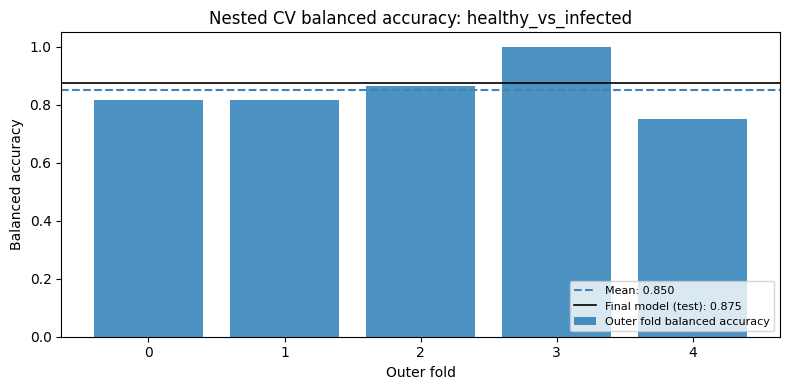

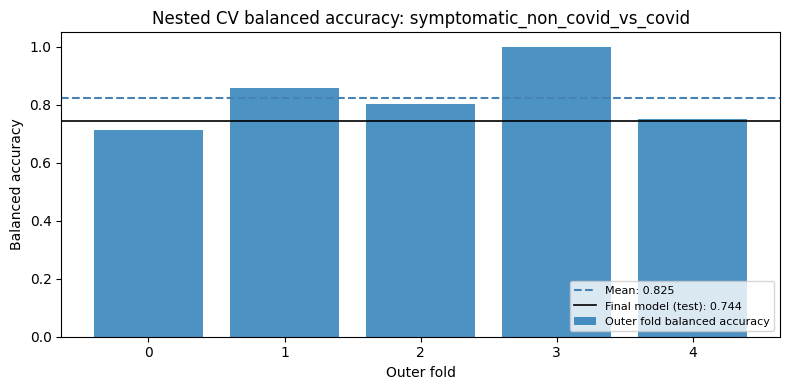

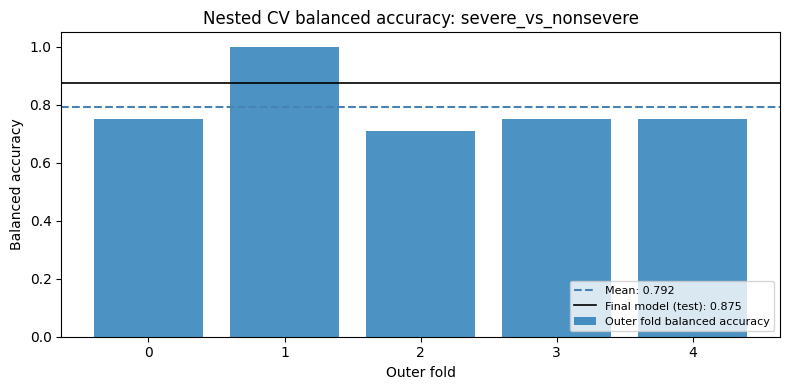

In [58]:
results_path = PROCESSED_DIR / "svm_results_all_tasks.csv"
results_df.to_csv(results_path, index=False)
print(f"Saved combined results table to: {results_path.resolve()}")

for task_name, data in task_data.items():
    task_dir = data["dir"]
    row = results_df[results_df["task"] == task_name].iloc[0]
    fold_df = pd.DataFrame(nested_cv_results[task_name])

    calibrated_pipeline = final_pipelines[task_name]
    y_test = data["y_test"]
    y_proba =  calibrated_pipeline.predict_proba(data["X_test"])[:, 1]

    # Plot nested CV balanced accuracy per fold
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(
        fold_df["fold"],
        fold_df["val_balanced_accuracy"],
        alpha=0.8,
        label="Outer fold balanced accuracy",
    )
    ax.axhline(
        fold_df["val_balanced_accuracy"].mean(),
        color="steelblue", linestyle="--", linewidth=1.5,
        label=f"Mean: {fold_df['val_balanced_accuracy'].mean():.3f}",
    )
    ax.axhline(
        row["test_balanced_accuracy"],
        color="black", linestyle="-", linewidth=1.2,
        label=f"Final model (test): {row['test_balanced_accuracy']:.3f}",
    )
    ax.set_xlabel("Outer fold")
    ax.set_ylabel("Balanced accuracy")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(fold_df["fold"])
    ax.set_title(f"Nested CV balanced accuracy: {task_name}")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    fig.savefig(
        task_dir / "svm_nested_cv_balanced_accuracy.png",
        dpi=300, bbox_inches="tight", facecolor="white", edgecolor="white",
    )
    plt.show()

    # Per-task CSVs 
    pd.DataFrame([row]).to_csv(task_dir / "svm_final_results.csv", index=False)
    fold_df.to_csv(task_dir / "svm_nested_cv_folds.csv", index=False)

# 6. Inspect best coefficients for each task

Extract the peptide features with the largest absolute coefficients from the inner SelectKBest + LinearSVC pipeline (before calibration wrapping). These are the SVM decision-boundary weights and correspond directly to peptide importance.

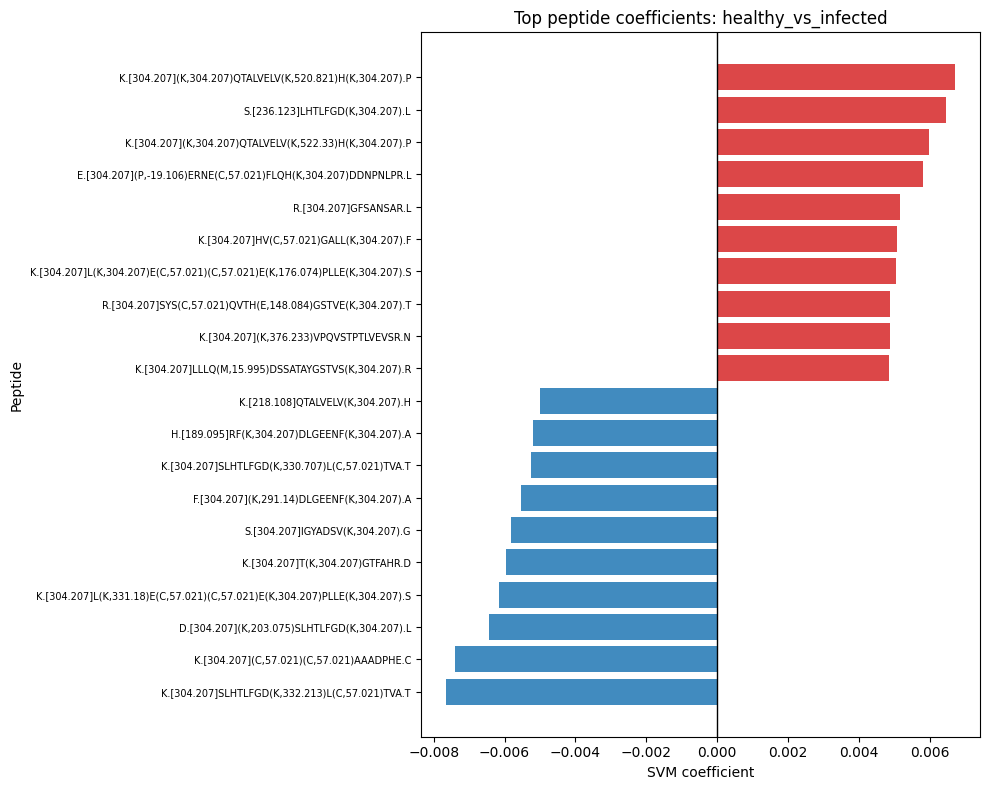

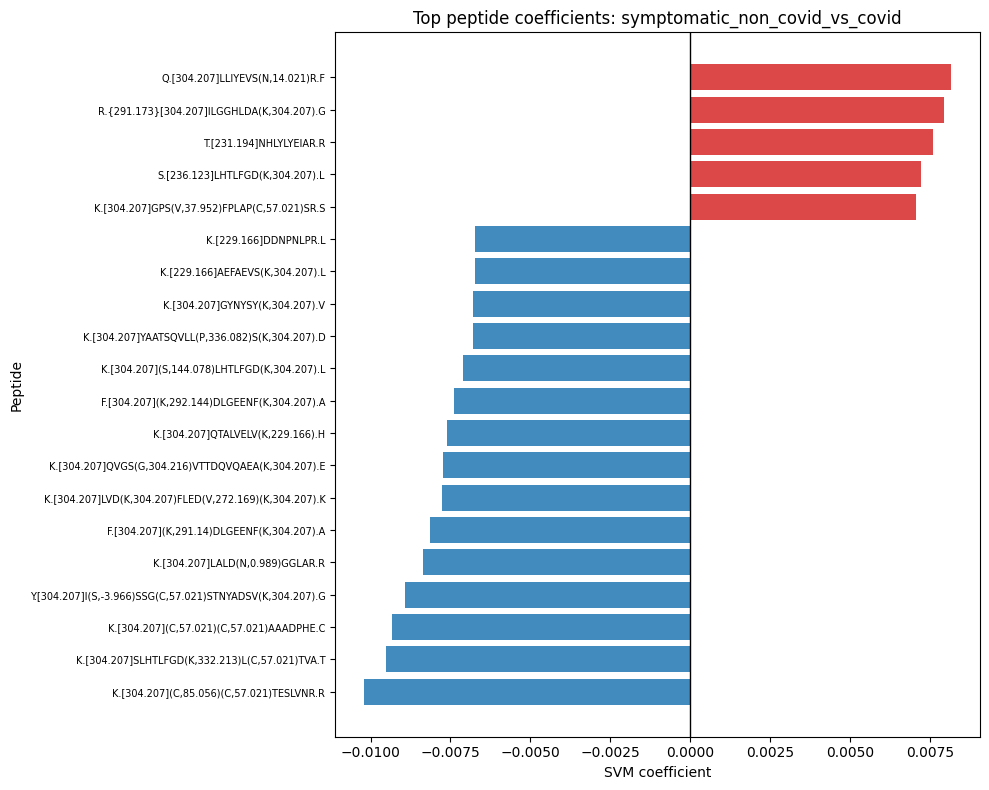

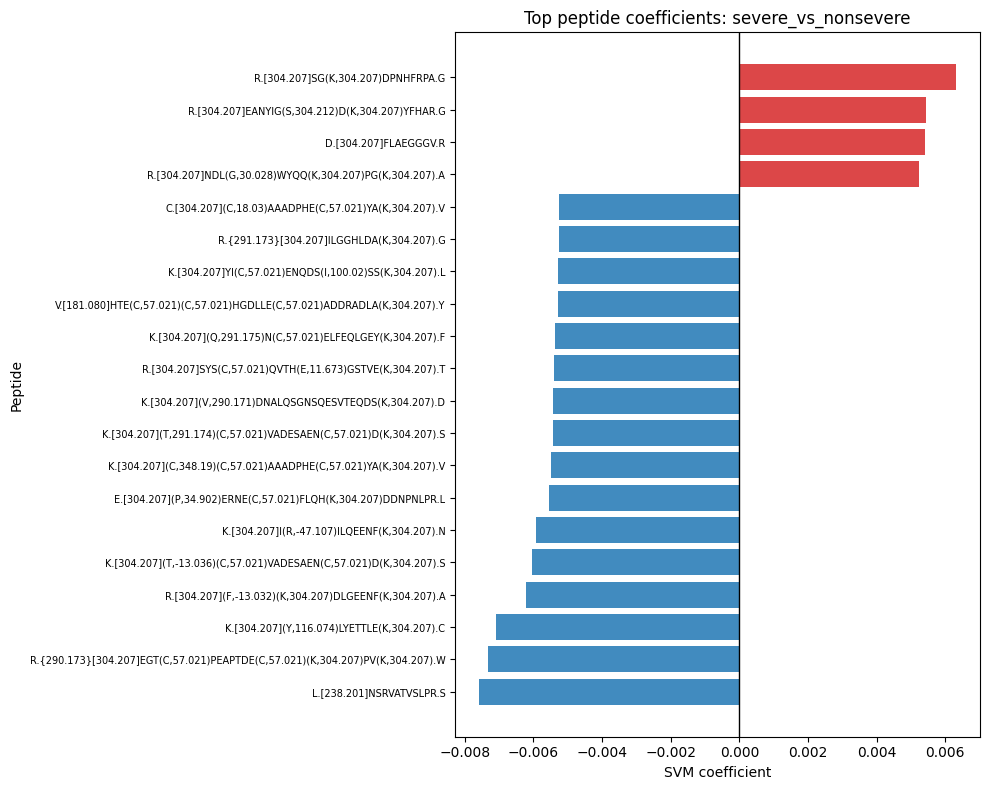

Top 5 peptides per task:

healthy_vs_infected
                                                peptide  coefficient
         K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T    -0.007645
               K.[304.207](C,57.021)(C,57.021)AAADPHE.C    -0.007396
K.[304.207](K,304.207)QTALVELV(K,520.821)H(K,304.207).P     0.006698
                        S.[236.123]LHTLFGD(K,304.207).L     0.006456
            D.[304.207](K,203.075)SLHTLFGD(K,304.207).L    -0.006433

symptomatic_non_covid_vs_covid
                                                 peptide  coefficient
                K.[304.207](C,85.056)(C,57.021)TESLVNR.R    -0.010195
          K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T    -0.009506
                K.[304.207](C,57.021)(C,57.021)AAADPHE.C    -0.009332
Y.[304.207]I(S,-3.966)SSG(C,57.021)STNYADSV(K,304.207).G    -0.008930
                         K.[304.207]LALD(N,0.989)GGLAR.R    -0.008361

severe_vs_nonsevere
                                                                   

In [59]:
coef_tables = {}

for task_name, data in task_data.items():
    calibrated_pipeline = final_pipelines[task_name]

    selector = calibrated_pipeline.named_steps["select"]
    cal_clf = calibrated_pipeline.named_steps["model"]  # CalibratedClassifierCV
    coef = np.mean([
        est.estimator.coef_.ravel()
        for est in cal_clf.calibrated_classifiers_
    ], axis=0)
    selected_feature_names = data["X_train"].columns[selector.get_support()]

    coef_df = pd.DataFrame({
        "task": task_name,
        "peptide": selected_feature_names,
        "coefficient": coef,
    })
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
    coef_tables[task_name] = coef_df

    task_dir = data["dir"]
    coef_df.to_csv(task_dir / "svm_top_coefficients.csv", index=False)

    # Plot and save
    top_coef_plot_df = coef_df.head(20).sort_values("coefficient")
    colors = np.where(top_coef_plot_df["coefficient"] >= 0, "tab:red", "tab:blue")
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top_coef_plot_df["peptide"], top_coef_plot_df["coefficient"], color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("SVM coefficient")
    ax.set_ylabel("Peptide")
    ax.set_title(f"Top peptide coefficients: {task_name}")
    ax.tick_params(axis="y", labelsize=7)
    plt.tight_layout()
    fig.savefig(
        task_dir / "svm_top_coefficients.png",
        dpi=300, bbox_inches="tight", facecolor="white", edgecolor="white",
    )
    plt.show()

print("Top 5 peptides per task:")
for task_name, coef_df in coef_tables.items():
    print(f"\n{task_name}")
    print(coef_df[["peptide", "coefficient"]].head(5).to_string(index=False))